In [1]:
# This script implements a convolutional neural network (CNN) on load_digits dataset of (8 X 8 X 1) grayscale images based on this architecture:
# Convolution -> Convolution -> MaxPool -> Flatten -> Fully Connected -> Fully Connected -> Fully Connected -> Softmax

import numpy as np
import matplotlib.pyplot as plt
import h5py
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from convLayer import convForward, convBackward
from poolLayer import poolForward, poolBackward
np.random.seed(42)

In [2]:
def relu(Z):
    return np.maximum(0, Z)

def reluBackward(dA, Z):
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def crossEntropyLoss(Y, Y_hat):
    m = Y.shape[0]
    log_likelihood = -np.log(Y_hat[range(m), Y])
    loss = np.sum(log_likelihood) / m
    return loss

Training samples: (1437, 8, 8, 1), Test samples: (360, 8, 8, 1)


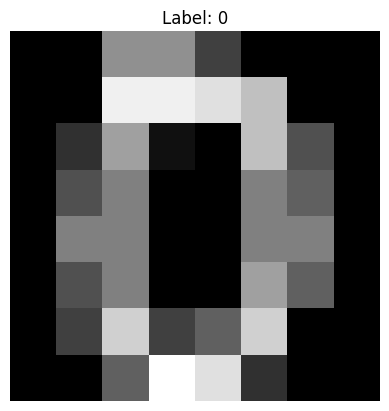

In [ ]:
digits = load_digits()
X = digits.images[..., np.newaxis] 
X = X / 16.0  
Y = digits.target[..., np.newaxis] 

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape}, Test samples: {X_test.shape}")

plt.imshow(X_train[1, :, :, 0], cmap='gray')
plt.title(f"Label: {y_train[1, 0]}")
plt.axis('off')
plt.show()

In [5]:
epochs = 50
alpha = 0.1
h_pool = {"f": 2, "stride": 2}
m_train = X_train.shape[0]

In [6]:
def he_init(shape):
    fan_in = np.prod(shape[:-1])
    return np.random.randn(*shape) * np.sqrt(2. / fan_in)

W_conv1 = he_init((4,4,1,4))
W_conv2 = he_init((2,2,4,8))
W_fc1   = np.random.randn(60, 72) * np.sqrt(2./72)
W_fc2   = np.random.randn(30, 60) * np.sqrt(2./60)
W_fc3   = np.random.randn(10, 30) * np.sqrt(2./30)
b_conv1 = np.zeros((1, 1, 1, 4))
b_conv2 = np.zeros((1, 1, 1, 8))
b_fc1 = np.zeros((60, 1))
b_fc2 = np.zeros((30, 1))
b_fc3 = np.zeros((10, 1))

In [8]:
losses = []
for epoch in range(epochs):
    #Forward prop
    Z1, cache_conv1 = convForward(X_train, W_conv1, b_conv1, {"stride": 1, "pad": 1})
    A1 = relu(Z1)
    Z2, cache_conv2 = convForward(A1, W_conv2, b_conv2, {"stride": 1, "pad": 0})
    A2 = relu(Z2)
    P, cache_pool = poolForward(A2, h_pool, "max")
    A_flat = P.reshape(P.shape[0], -1)
    A_flat = A_flat.T 
    Z3 = np.dot(W_fc1, A_flat) + b_fc1
    A3 = relu(Z3)
    Z4 = np.dot(W_fc2, A3) + b_fc2
    A4 = relu(Z4)
    Z5 = np.dot(W_fc3, A4) + b_fc3
    Y_hat = softmax(Z5.T)
    loss = crossEntropyLoss(y_train.flatten(), Y_hat)
    losses.append(loss)
    print(f"Epoch {epoch+1:>3}/{epochs}, Loss: {loss:.4f}")
    
    #Backward prop
    d_logits = Y_hat.copy()
    d_logits[range(m_train), y_train.flatten()] -= 1
    d_logits /= m_train
    d_logits = d_logits.T 
    dW3_fc = np.dot(A4, d_logits.T).T
    db3_fc = np.sum(d_logits.T, axis=0, keepdims=True).T
    dA4 = np.dot(W_fc3.T, d_logits)
    dZ4 = reluBackward(dA4, Z4)
    dW2_fc = np.dot(A3, dZ4.T).T
    db2_fc = np.sum(dZ4.T, axis=0, keepdims=True).T
    dA3 = np.dot(W_fc2.T, dZ4)
    dZ3 = reluBackward(dA3, Z3)
    dW1_fc = np.dot(A_flat, dZ3.T).T
    db1_fc = np.sum(dZ3.T, axis=0, keepdims=True).T
    dflat = np.dot(W_fc1.T, dZ3)
    dP = dflat.reshape(P.shape)
    dA2 = poolBackward(dP, cache_pool, "max")
    dZ2 = reluBackward(dA2, Z2)
    dA1, dW2_conv, db2_conv = convBackward(dZ2, cache_conv2)
    dZ1 = reluBackward(dA1, Z1)
    dA0, dW1_conv, db1_conv = convBackward(dZ1, cache_conv1)
    
    #Update parameters
    W_conv1 -= alpha * dW1_conv
    b_conv1 -= alpha * db1_conv
    W_conv2 -= alpha * dW2_conv
    b_conv2 -= alpha * db2_conv
    W_fc1 -= alpha * dW1_fc
    b_fc1 -= alpha * db1_fc
    W_fc2 -= alpha * dW2_fc
    b_fc2 -= alpha * db2_fc
    W_fc3 -= alpha * dW3_fc
    b_fc3 -= alpha * db3_fc
    # if epoch % 5 == 0:
    #     print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch   1/50, Loss: 2.5617
Epoch   2/50, Loss: 2.4184
Epoch   3/50, Loss: 2.3731
Epoch   4/50, Loss: 2.3438
Epoch   5/50, Loss: 2.3216
Epoch   6/50, Loss: 2.3028
Epoch   7/50, Loss: 2.2860
Epoch   8/50, Loss: 2.2704
Epoch   9/50, Loss: 2.2555
Epoch  10/50, Loss: 2.2414
Epoch  11/50, Loss: 2.2277
Epoch  12/50, Loss: 2.2143
Epoch  13/50, Loss: 2.2008
Epoch  14/50, Loss: 2.1871
Epoch  15/50, Loss: 2.1733
Epoch  16/50, Loss: 2.1591
Epoch  17/50, Loss: 2.1450
Epoch  18/50, Loss: 2.1305
Epoch  19/50, Loss: 2.1158
Epoch  20/50, Loss: 2.1011
Epoch  21/50, Loss: 2.0862
Epoch  22/50, Loss: 2.0708
Epoch  23/50, Loss: 2.0548
Epoch  24/50, Loss: 2.0381
Epoch  25/50, Loss: 2.0206
Epoch  26/50, Loss: 2.0021
Epoch  27/50, Loss: 1.9833
Epoch  28/50, Loss: 1.9641
Epoch  29/50, Loss: 1.9448
Epoch  30/50, Loss: 1.9247
Epoch  31/50, Loss: 1.9043
Epoch  32/50, Loss: 1.8836
Epoch  33/50, Loss: 1.8629
Epoch  34/50, Loss: 1.8416
Epoch  35/50, Loss: 1.8206
Epoch  36/50, Loss: 1.7995
Epoch  37/50, Loss: 1.7775
E

Training accuracy: 0.6124
Test accuracy: 0.5889


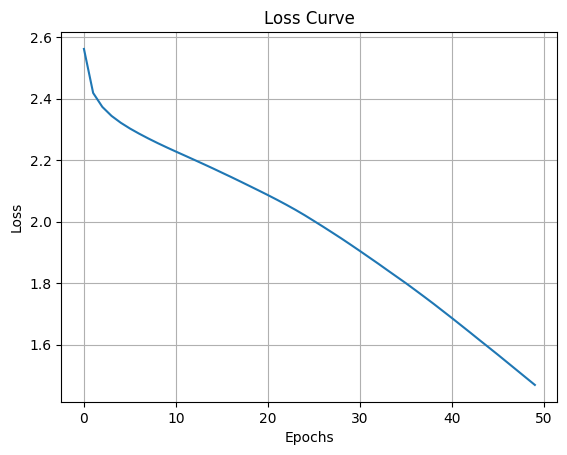

In [9]:
def evaluate(X, Y):
    Z1, _ = convForward(X, W_conv1, b_conv1, {"stride": 1, "pad": 1})
    A1 = relu(Z1)
    Z2, _ = convForward(A1, W_conv2, b_conv2, {"stride": 1, "pad": 0})
    A2 = relu(Z2)
    P, _ = poolForward(A2, h_pool, "max")
    A_flat = P.reshape(P.shape[0], -1).T
    Z3 = np.dot(W_fc1, A_flat) + b_fc1
    A3 = relu(Z3)
    Z4 = np.dot(W_fc2, A3) + b_fc2
    A4 = relu(Z4)
    Z5 = np.dot(W_fc3, A4) + b_fc3
    Y_hat = softmax(Z5.T)
    preds = np.argmax(Y_hat, axis=1)
    accuracy = np.mean(preds == Y.flatten())
    return accuracy

print(f"Training accuracy: {evaluate(X_train, y_train):.4f}")
print(f"Test accuracy: {evaluate(X_test, y_test):.4f}")

#Plotting the loss curve
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()